# Sanskrit → English Neural Machine Translation
### Custom Transformer seq2seq (from scratch, PyTorch) with SentencePiece subwords

**Roll Number:** g25ait1215

(BLEU, BERTScore F1, inference time, parameter count).


## 0. Environment check


In [2]:
import sys, platform
print("Python :", sys.version.split()[0])
print("Executable:", sys.executable)
print("Platform :", platform.platform())

Python : 3.12.13
Executable: /usr/bin/python3
Platform : Linux-6.6.122+-x86_64-with-glibc2.35


## 1. Install dependencies


In [3]:
import sys, subprocess

def pip_install(pkgs, extra=None):
    cmd = [sys.executable, "-m", "pip", "install", "-q"] + pkgs
    if extra: cmd += extra
    print("Installing:", " ".join(pkgs), "...", flush=True)
    r = subprocess.run(cmd)
    print("  ->", "OK" if r.returncode == 0 else f"FAILED (code {r.returncode})", flush=True)


pip_install(["torch"], extra=["--index-url", "https://download.pytorch.org/whl/cpu"])
pip_install(["sentencepiece", "nltk", "bert-score", "pandas", "numpy", "tqdm", "matplotlib"])

import nltk
nltk.download("punkt", quiet=True)
print("\nAll dependencies ready.")

Installing: torch ...
  -> OK
Installing: sentencepiece nltk bert-score pandas numpy tqdm matplotlib ...
  -> OK

All dependencies ready.


## 2. Imports, seed, and configuration


In [4]:
import os, time, math, random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

class CFG:
    # ---- data paths ----
    data_dir = "."
    train_sa = "train_sa_10000.csv"; train_en = "train_en_10000.csv"
    dev_sa   = "dev_sa_1000.csv";    dev_en   = "dev_en_1000.csv"
    test_sa  = "test_sa_1000.csv";   test_en  = "test_en_1000.csv"

    # ---- tokenizer ----
    vocab_size = 8000
    spm_prefix = "spm_shared"

    # ---- model (compact Transformer) ----
    d_model = 256; nhead = 4
    num_encoder_layers = 4; num_decoder_layers = 4
    dim_ff = 1024; dropout = 0.1; max_len = 96

    # ---- training ----
    batch_size = 64
    epochs = 20            # early stopping usually halts sooner
    lr = 5e-4; warmup = 2000
    label_smoothing = 0.1
    grad_clip = 1.0; weight_decay = 1e-2
    patience = 4

    # ---- decoding ----
    beam_size = 5; length_penalty = 0.7

    # ---- CPU throughput ----
    num_threads = max(1, os.cpu_count() or 1)

    device = "cuda" if torch.cuda.is_available() else "cpu"
    ckpt = "best_model.pt"

cfg = CFG()
torch.set_num_threads(cfg.num_threads)
print(f"Device: {cfg.device} | CPU threads: {cfg.num_threads}")
if cfg.device == "cpu":
    print("Running on CPU — training will take a while. Progress prints after every epoch.")

Device: cuda | CPU threads: 2


## 3. Load & preprocess data
Align on `Source_id`, normalise whitespace, drop empty pairs. Sanskrit stays in Devanagari.

In [7]:
import re

def clean(s):
    s = str(s).replace("\r", " ").replace("\n", " ")
    return re.sub(r"\s+", " ", s).strip()

def load_pair(sa_file, en_file):
    sa = pd.read_csv(os.path.join(cfg.data_dir, sa_file))
    en = pd.read_csv(os.path.join(cfg.data_dir, en_file))
    sa.columns = ["Source_id", "Sentence_sa"]
    en.columns = ["Source_id", "Sentence_en"]
    df = sa.merge(en, on="Source_id", how="inner")
    df["Sentence_sa"] = df["Sentence_sa"].map(clean)
    df["Sentence_en"] = df["Sentence_en"].map(clean)
    df = df[(df.Sentence_sa.str.len() > 0) & (df.Sentence_en.str.len() > 0)].reset_index(drop=True)
    return df

# test target may or may not be present at grading time; load defensively.
train_df = load_pair(cfg.train_sa, cfg.train_en)
dev_df   = load_pair(cfg.dev_sa,   cfg.dev_en)
try:
    test_df = load_pair(cfg.test_sa, cfg.test_en)
    HAS_TEST_REF = True
except Exception as e:
    ts = pd.read_csv(os.path.join(cfg.data_dir, cfg.test_sa)); ts.columns = ["Source_id","Sentence_sa"]
    ts["Sentence_sa"] = ts["Sentence_sa"].map(clean); ts["Sentence_en"] = ""
    test_df = ts; HAS_TEST_REF = False
    print("No test reference found — will still write submission.csv. (", e, ")")

print(f"train={len(train_df)}  dev={len(dev_df)}  test={len(test_df)}  test_refs={HAS_TEST_REF}")
train_df.head(3)

train=10000  dev=1000  test=1000  test_refs=True


,Source_id,Sentence_sa,Sentence_en
0,1,"""Ctrl, S नुत्वा रक्षन्तु।""","Save it with Ctrl, S."
1,2,गुरुः छात्रान् एकवारं पाठयति ।,Teacher will teach the students only once.
2,3,चित्रचालनमिदं पुनः कर्तुं मया अस्याः राशेः चित...,"To recreate this animation, I have to take two..."


## 4. Shared SentencePiece tokenizer
One vocab over both languages lets us tie the embeddings and the output projection (big parameter saving). Trained only on the training data.

In [8]:
import sentencepiece as spm

PAD, UNK, BOS, EOS = 0, 1, 2, 3
CORPUS = "spm_corpus.txt"
model_file = cfg.spm_prefix + ".model"

if not os.path.exists(model_file):
    print("Training SentencePiece tokenizer ...", flush=True)
    with open(CORPUS, "w", encoding="utf-8") as f:
        for t in list(train_df.Sentence_sa) + list(train_df.Sentence_en):
            f.write(t + "\n")
    spm.SentencePieceTrainer.Train(
        input=CORPUS, model_prefix=cfg.spm_prefix,
        vocab_size=cfg.vocab_size, model_type="unigram", character_coverage=1.0,
        pad_id=PAD, unk_id=UNK, bos_id=BOS, eos_id=EOS,
        pad_piece="<pad>", unk_piece="<unk>", bos_piece="<s>", eos_piece="</s>")
    print("  done.")
else:
    print("Tokenizer already exists — reusing", model_file)

sp = spm.SentencePieceProcessor(model_file=model_file)
VOCAB = sp.get_piece_size()
print("Vocab size:", VOCAB)
print("Sample encode:", sp.encode("ते वीराः ।", out_type=int))

Training SentencePiece tokenizer ...
  done.
Vocab size: 8000
Sample encode: [301, 378, 2446, 141, 9]


## 5. Dataset & batching
Encode to subword ids, add `<s>`/`</s>`, truncate to `max_len`, dynamically pad each batch.

In [9]:
def encode(text, add_bos=False, add_eos=True):
    ids = sp.encode(text, out_type=int)[: cfg.max_len - 2]
    if add_bos: ids = [BOS] + ids
    if add_eos: ids = ids + [EOS]
    return ids

class MTDataset(Dataset):
    def __init__(self, df, has_tgt=True):
        self.src = [encode(s, add_bos=False, add_eos=True) for s in df.Sentence_sa]
        self.tgt = [encode(t, add_bos=True, add_eos=True) for t in df.Sentence_en] if has_tgt else None
    def __len__(self): return len(self.src)
    def __getitem__(self, i):
        return self.src[i], (self.tgt[i] if self.tgt is not None else [BOS, EOS])

def collate(batch):
    srcs, tgts = zip(*batch)
    def pad(seqs):
        m = max(len(s) for s in seqs)
        return torch.tensor([s + [PAD] * (m - len(s)) for s in seqs], dtype=torch.long)
    return pad(srcs), pad(tgts)

train_ds = MTDataset(train_df)
dev_ds   = MTDataset(dev_df)
train_dl = DataLoader(train_ds, cfg.batch_size, shuffle=True,  collate_fn=collate)
dev_dl   = DataLoader(dev_ds,   cfg.batch_size, shuffle=False, collate_fn=collate)
print("train batches/epoch:", len(train_dl), "| dev batches:", len(dev_dl))

train batches/epoch: 157 | dev batches: 16


## 6. Model — custom Transformer
Encoder, decoder, multi-head attention, positional encoding and masking are all defined here.
Source/target embeddings and the output projection are **weight-tied**.

In [10]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div); pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))
    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])

class TransformerNMT(nn.Module):
    def __init__(self, cfg, vocab):
        super().__init__()
        self.d_model = cfg.d_model
        self.embed = nn.Embedding(vocab, cfg.d_model, padding_idx=PAD)
        self.pos = PositionalEncoding(cfg.d_model, cfg.max_len + 8, cfg.dropout)
        enc = nn.TransformerEncoderLayer(cfg.d_model, cfg.nhead, cfg.dim_ff, cfg.dropout,
                                         batch_first=True, norm_first=True)
        dec = nn.TransformerDecoderLayer(cfg.d_model, cfg.nhead, cfg.dim_ff, cfg.dropout,
                                         batch_first=True, norm_first=True)
        self.encoder = nn.TransformerEncoder(enc, cfg.num_encoder_layers)
        self.decoder = nn.TransformerDecoder(dec, cfg.num_decoder_layers)
        self.proj = nn.Linear(cfg.d_model, vocab, bias=False)
        self.proj.weight = self.embed.weight            # weight tying
        for p in self.parameters():
            if p.dim() > 1: nn.init.xavier_uniform_(p)
    def _pad_mask(self, x): return x == PAD
    def encode(self, src):
        h = self.pos(self.embed(src) * math.sqrt(self.d_model))
        return self.encoder(h, src_key_padding_mask=self._pad_mask(src))
    def decode(self, tgt, mem, src):
        L = tgt.size(1)
        causal = torch.triu(torch.ones(L, L, device=tgt.device), 1).bool()
        h = self.pos(self.embed(tgt) * math.sqrt(self.d_model))
        h = self.decoder(h, mem, tgt_mask=causal,
                         tgt_key_padding_mask=self._pad_mask(tgt),
                         memory_key_padding_mask=self._pad_mask(src))
        return self.proj(h)
    def forward(self, src, tgt_in):
        return self.decode(tgt_in, self.encode(src), src)

model = TransformerNMT(cfg, VOCAB).to(cfg.device)
N_PARAMS = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {N_PARAMS:,}")

/tmp/ipykernel_2559/3008009270.py:23: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc, cfg.num_encoder_layers)


Total parameters: 9,420,800


## 7. Training
Label-smoothed cross-entropy, AdamW, inverse-sqrt warmup, gradient clipping, early stopping on dev
loss. **Progress prints after every epoch** (and a heartbeat every 50 batches). The best checkpoint is saved to disk.

In [11]:
crit = nn.CrossEntropyLoss(ignore_index=PAD, label_smoothing=cfg.label_smoothing)
opt = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay,
                        betas=(0.9, 0.98), eps=1e-9)

def lr_at(step):
    step = max(step, 1)
    return cfg.d_model ** -0.5 * min(step ** -0.5, step * cfg.warmup ** -1.5)

_step = 0
def run_epoch(dl, train=True, tag=""):
    global _step
    model.train(train)
    total, ntok = 0.0, 0
    t0 = time.time()
    for bi, (src, tgt) in enumerate(dl):
        src, tgt = src.to(cfg.device), tgt.to(cfg.device)
        tgt_in, tgt_out = tgt[:, :-1], tgt[:, 1:]
        with torch.set_grad_enabled(train):
            logits = model(src, tgt_in)
            loss = crit(logits.reshape(-1, VOCAB), tgt_out.reshape(-1))
            if train:
                opt.zero_grad(); loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
                _step += 1
                for g in opt.param_groups: g["lr"] = lr_at(_step)
                opt.step()
        n = (tgt_out != PAD).sum().item()
        total += loss.item() * n; ntok += n
        if train and bi % 50 == 0:
            print(f"    {tag} batch {bi:4d}/{len(dl)}  loss {loss.item():.3f}  "
                  f"({time.time()-t0:.0f}s)", flush=True)
    return total / max(ntok, 1)

history, best, bad = [], float("inf"), 0
print("Starting training ...\n", flush=True)
for ep in range(1, cfg.epochs + 1):
    te = time.time()
    tr = run_epoch(train_dl, True, tag=f"ep{ep}")
    with torch.no_grad():
        dv = run_epoch(dev_dl, False)
    history.append((ep, tr, dv))
    flag = ""
    if dv < best:
        best, bad = dv, 0
        torch.save(model.state_dict(), cfg.ckpt); flag = "  <- best (saved)"
    else:
        bad += 1
    print(f"epoch {ep:2d} | train {tr:.3f} | dev {dv:.3f} | ppl {math.exp(min(dv,20)):6.1f} "
          f"| {time.time()-te:.0f}s{flag}", flush=True)
    if bad >= cfg.patience:
        print("Early stopping (no dev improvement).", flush=True); break

model.load_state_dict(torch.load(cfg.ckpt, map_location=cfg.device))
print(f"\nLoaded best checkpoint (dev loss = {best:.3f}).")

Starting training ...

    ep1 batch    0/157  loss 9.321  (1s)
    ep1 batch   50/157  loss 7.770  (6s)
    ep1 batch  100/157  loss 6.821  (11s)
    ep1 batch  150/157  loss 6.625  (16s)
epoch  1 | train 7.466 | dev 6.545 | ppl  695.9 | 17s  <- best (saved)
    ep2 batch    0/157  loss 6.621  (0s)
    ep2 batch   50/157  loss 6.401  (5s)
    ep2 batch  100/157  loss 6.361  (10s)
    ep2 batch  150/157  loss 6.192  (15s)
epoch  2 | train 6.402 | dev 6.130 | ppl  459.3 | 16s  <- best (saved)
    ep3 batch    0/157  loss 6.033  (0s)
    ep3 batch   50/157  loss 6.002  (5s)
    ep3 batch  100/157  loss 5.880  (10s)
    ep3 batch  150/157  loss 5.705  (15s)
epoch  3 | train 5.928 | dev 5.652 | ppl  284.7 | 16s  <- best (saved)
    ep4 batch    0/157  loss 5.709  (0s)
    ep4 batch   50/157  loss 5.604  (5s)
    ep4 batch  100/157  loss 5.402  (10s)
    ep4 batch  150/157  loss 5.301  (16s)
epoch  4 | train 5.492 | dev 5.401 | ppl  221.6 | 17s  <- best (saved)
    ep5 batch    0/157  loss 

### 7.1 Training curve

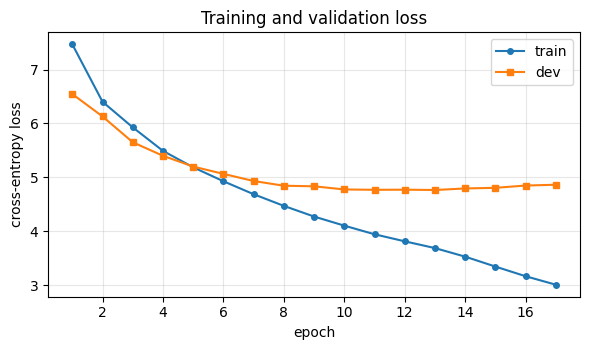

Saved training_curve.png


In [12]:
import matplotlib.pyplot as plt
h = np.array(history)
plt.figure(figsize=(6, 3.6))
plt.plot(h[:,0], h[:,1], marker="o", ms=4, label="train")
plt.plot(h[:,0], h[:,2], marker="s", ms=4, label="dev")
plt.xlabel("epoch"); plt.ylabel("cross-entropy loss"); plt.legend()
plt.title("Training and validation loss"); plt.grid(alpha=.3); plt.tight_layout()
plt.savefig("training_curve.png", dpi=140); plt.show()
print("Saved training_curve.png")

## 8. Beam-search decoding
Beam width 5 with length normalization. Falls back gracefully and strips special tokens.

In [13]:
@torch.no_grad()
def beam_translate(src_ids, beam=None, max_len=None, lp=None):
    beam = beam or cfg.beam_size
    max_len = max_len or cfg.max_len
    lp = cfg.length_penalty if lp is None else lp
    model.eval()
    src = torch.tensor([src_ids], device=cfg.device)
    mem = model.encode(src)
    beams = [([BOS], 0.0)]; completed = []
    for _ in range(max_len):
        cand = []
        for seq, score in beams:
            if seq[-1] == EOS:
                completed.append((seq, score)); continue
            tgt = torch.tensor([seq], device=cfg.device)
            logp = F.log_softmax(model.decode(tgt, mem, src)[:, -1], -1).squeeze(0)
            topv, topi = logp.topk(beam)
            for v, i in zip(topv.tolist(), topi.tolist()):
                cand.append((seq + [i], score + v))
        if not cand: break
        cand.sort(key=lambda x: x[1] / (len(x[0]) ** lp), reverse=True)
        beams = cand[:beam]
        if all(s[-1] == EOS for s, _ in beams):
            completed.extend(beams); break
    pool = completed if completed else beams
    best_seq = max(pool, key=lambda x: x[1] / (len(x[0]) ** lp))[0]
    ids = [i for i in best_seq if i not in (BOS, EOS, PAD)]
    return sp.decode(ids)

# sanity check
print("SRC:", dev_df.Sentence_sa.iloc[0])
print("REF:", dev_df.Sentence_en.iloc[0])
print("HYP:", beam_translate(encode(dev_df.Sentence_sa.iloc[0])))

SRC: ते वीराः ।
REF: Those are brave men.
HYP: Those are they.


## 9. Translate the test set + measure inference time

In [15]:
from tqdm.auto import tqdm

def translate_all(df):
    preds = []
    t0 = time.time()
    for s in tqdm(df.Sentence_sa, desc="translating test"):
        preds.append(beam_translate(encode(s)))
    return preds, time.time() - t0

test_preds, INFER_TIME = translate_all(test_df)
print(f"\nInference time (test, {len(test_df)} sentences): {INFER_TIME:.1f}s "
      f"({INFER_TIME/len(test_df)*1000:.1f} ms/sentence)")

translating test:   0%|          | 0/1000 [00:00<?, ?it/s]


Inference time (test, 1000 sentences): 1921.5s (1921.5 ms/sentence)


## 10. Write submission.csv
Exactly two columns — `Source_id`, `Sentence_en` — UTF-8 encoded.

In [16]:
submission = pd.DataFrame({"Source_id": test_df.Source_id.values,
                           "Sentence_en": test_preds})
submission.to_csv("submission.csv", index=False, encoding="utf-8")
print("Wrote submission.csv", submission.shape)
submission.head()

Wrote submission.csv (1000, 2)


,Source_id,Sentence_en
0,1,"""And the Eclipse, let us look at the Eclipse, ..."
1,2,"""Remembering the faith in the faith, and the f..."
2,3,"Then, we shall see that the list of the data a..."
3,4,As an assignment should be seted to the index ...
4,5,"""And the second second second second second an..."


## 11. Evaluation — BLEU, BERTScore, Efficiency
BLEU uses NLTK corpus BLEU with default weights. BERTScore reports rescaled F1. Runs only if test references are available.

In [17]:
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

if HAS_TEST_REF:
    refs = [[r.split()] for r in test_df.Sentence_en]
    hyps = [p.split() for p in test_preds]
    smooth = SmoothingFunction().method1
    BLEU = corpus_bleu(refs, hyps, smoothing_function=smooth)
    print(f"BLEU (NLTK corpus, default weights): {BLEU*100:.2f}")
else:
    BLEU = None
    print("No test references — skipping BLEU (submission.csv still written).")

BLEU (NLTK corpus, default weights): 6.50


In [18]:
if HAS_TEST_REF:
    from bert_score import score as bertscore
    P, R, F1 = bertscore(test_preds, list(test_df.Sentence_en),
                         lang="en", rescale_with_baseline=True, verbose=True)
    BERT_F1 = F1.mean().item()
    print(f"BERTScore F1 (rescaled): {BERT_F1:.4f}")
else:
    BERT_F1 = None
    print("No test references — skipping BERTScore.")

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

calculating scores...
computing bert embedding.


  0%|          | 0/31 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/16 [00:00<?, ?it/s]

done in 8.47 seconds, 118.13 sentences/sec
BERTScore F1 (rescaled): 0.3015


In [19]:
print("=" * 48)
print("SUMMARY")
print("=" * 48)
print(f"Total parameters       : {N_PARAMS:,}")
print(f"Inference time (test)  : {INFER_TIME:.1f} s  ({INFER_TIME/len(test_df)*1000:.1f} ms/sent)")
if BLEU is not None:    print(f"BLEU                   : {BLEU*100:.2f}")
if BERT_F1 is not None: print(f"BERTScore F1 (rescaled): {BERT_F1:.4f}")
print("=" * 48)

SUMMARY
Total parameters       : 9,420,800
Inference time (test)  : 1921.5 s  (1921.5 ms/sent)
BLEU                   : 6.50
BERTScore F1 (rescaled): 0.3015


## 12. Translation examples (for the report)

In [20]:
k = min(8, len(test_df))
for i in range(k):
    print("SRC :", test_df.Sentence_sa.iloc[i])
    if HAS_TEST_REF: print("REF :", test_df.Sentence_en.iloc[i])
    print("PRED:", test_preds[i])
    print("-" * 80)

SRC : एक्लिप्स् इति प्रोग्रामर् कृते दोषान्वेषणे अपि साहाय्यं करोति।
REF : Eclipse also helps the programmer to find out errors.
PRED: "And the Eclipse, let us look at the Eclipse, and the Eclipse IDE."
--------------------------------------------------------------------------------
SRC : विश्वासकारणादेव समभाषि मया वचः। इति यथा शास्त्रे लिखितं तथैवास्माभिरपि विश्वासजनकम् आत्मानं प्राप्य विश्वासः क्रियते तस्माच्च वचांसि भाष्यन्ते।
REF : "We having the same spirit of faith, according as it is written, I believed, and therefore have I spoken; we also believe, and therefore speak;"
PRED: "Remembering the faith in the faith, and the faith in the faith, that the faith should be the faith in the faith of faith."
--------------------------------------------------------------------------------
SRC : तदा, तत्स्वयं ड्रैवर निमित्तम् अन्वेष्यति। अहं 'Cancel' इत्यस्योपरि नुदामि।
REF : Then it will automatically begin searching for drivers. I will click on Cancel.
PRED: Then, we shall see that the li

## Disclosure & reproducibility (for the report)
- Translation model trained **from scratch** — no pretrained translation weights.
- Only pretrained artifact: the RoBERTa model inside **bert-score**, used **for evaluation only**.
- Tokenizer: SentencePiece unigram, shared 8k vocab, trained only on the provided training data.
- **No external APIs** are called anywhere.
- Seed fixed at 42. Set `CFG` values to reproduce.